In [ ]:
## Helper Functions -- no edits required
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings
warnings.filterwarnings('ignore', category=FutureWarning)


# Make console tables wide and avoid multi-line wrapping
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)            # adjust if your terminal is wider
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.colheader_justify', 'center')

def _print_table(df: pd.DataFrame, title: str, round_to=3):
    df = df.copy()
    # round numeric columns for compactness
    for c in df.select_dtypes(include=[np.number]).columns:
        df[c] = df[c].round(round_to)

    # Shorten very long method names to keep one-line rows
    if 'method' in df.columns:
        df['method'] = df['method'].apply(lambda s: s if len(str(s)) <= 38 else str(s)[:35] + '...')

    # Prefer tabulate if available for nice ASCII tables
    try:
        from tabulate import tabulate  # pip install tabulate
        print(f"\n{title}")
        print(tabulate(df, headers='keys', tablefmt='psql', showindex=False))
    except Exception:
        # Fallback: pandas pretty print with generous column spacing
        print(f"\n{title}")
        print(df.to_string(index=False, col_space=12, max_rows=None))





def load_filter_pairs(filter_file):
    """
    Loads pairs of anchor and query indices from a text file.

    Args:
        filter_file: Path to the text file containing pairs. Each line should contain two integers
                     separated by a comma (e.g., "123,456").

    Returns:
        A set of tuples (anchor_idx, query_idx) representing the pairs to be filtered.
        Returns an empty set if the file is not found or an error occurs.
    """
    try:
        with open(filter_file, 'r') as f:
            pairs = set()
            for line in f:
                try:
                    anchor_idx, query_idx = map(int, line.strip().split(' '))
                    pairs.add((anchor_idx, query_idx))
                except ValueError:
                    print(f"Warning: Invalid line in filter file: {line.strip()}")
            return pairs
    except FileNotFoundError:
        print(f"Warning: Filter file not found at {filter_file}")
        return set()
    except Exception as e:
        print(f"An error occurred while loading the filter file: {e}")
        return set()

def load_statistics(pointcloud_type, base_paths, scene_names, base_path_index, filter_files=None, split='all'):
    """
    Loads statistics from CSV files from multiple base paths and applies a filter for specific pairs.

    Args:
        pointcloud_type: The type of point cloud (e.g., 'lidar', 'mast3r').
        base_paths: A list of base directories where the CSV files are stored.
        scene_names: A list of scene names to load data from.
        base_path_index: The index of the base path in the base_paths list.
        filter_files: A dictionary of filter files, where keys are scene names and values are the corresponding filter file paths.
                      If None, no filtering is applied.

    Returns:
        A pandas DataFrame containing the loaded statistics, or None if no file is found.
    """
    dfs = []
    for base_path in base_paths:
        for scene_name in scene_names:
            csv_file = os.path.join(base_path, f"{scene_name}", f"{pointcloud_type}.csv")
            # print(f"Attempting to load: {csv_file}")  # Debugging print
            try:
                df = pd.read_csv(csv_file)

            # Construct filter file path based on scene name
                filter_file = f"pairs_finetuning/{scene_name}/{split}_pairs.txt"
                # print(filter_file, split)
                if os.path.exists(filter_file):
                    filter_pairs = load_filter_pairs(filter_file)
                    # Create a combined column for filtering
                    df['pair_id'] = list(zip(df['anchor_idx'], df['query_idx']))

                    # Filter the DataFrame
                    df = df[df['pair_id'].isin(filter_pairs)]

                    # Remove the temporary column
                    df = df.drop(columns=['pair_id'])
                else:
                    print(f"Warning: Filter file not found for scene {scene_name} at {filter_file}.  No filtering applied.")

                df['base_path'] = base_path  # Add a column to identify the base path
                df['pointcloud_type'] = pointcloud_type  # Add a column to identify the pointcloud type
                df['model_number'] = base_path_index  # Add the model number
                df['scene_name'] = scene_name  # Add scene name
                dfs.append(df)
            except FileNotFoundError:
                print(f"Warning: CSV file not found for {pointcloud_type} at {csv_file}")

    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True)
        return combined_df
    else:
        return None
    
    

### Generating Table 2, 8, 9

The README shows the type of output files generated per experiment. Here, the `"path"` variable needs to be changed in the `BASE_PATHS` definition. 

- If the output path is `<results>/<model_name>/` (which can be fine-tuned/pre-trained MASt3R or the output generated for `apply_train_scales.sh`)
    - This should contain `.csv` files for the output type (which may be `mast3r`, `lidar`, `mast3r_scaled_<type>` or `<monocular_depth_model>`).   


In [12]:
# INPUT REQUIRED - Define base paths and pointcloud types 


BASE_PATHS = {
    "model_0": {
        "path": "results_localization/original/",
        "types": ['mast3r', 'lidar', 'mast3r_scaled_v4', 'mast3r_scaled_v3','mast3r_scaled_v2','mast3r_scaled_icp'],
        "display_name": "MASt3R Pre-trained"
    },
    "model_1": {
        "path": "/home/bjangley/VPR/mast3r-v2/results_localization/original_conf40",
        "types": ['mast3r'],
        "display_name": "MASt3R Pre-trained Confidence Thresholded"
    },
    "model_2": {
        "path": "results_localization/original/",
        "types": ['anydepth80'],
        "display_name": "Depth Anything V2"
    },
    "model_3": {
        "path": "results_localization/original",
        "types": ['zoedepth'],
        "display_name": "ZoeDepth"
    },    
    "model_4": {
        "path": "/home/bjangley/VPR/mast3r-v2/results_localization/campus_ciampino2_lr5e5_3e6_reg",
        "types": ['mast3r'],
        "display_name": "Finetuned Model (Campus, Ciampino2)"
    },
    "model_5": {
        "path": "/home/bjangley/VPR/mast3r-v2/results_localization/ciampino1_ciampino2_lr5e5_3e6_reg",
        "types": ['mast3r'],
        "display_name": "Finetuned Model (Ciampino1, Ciampino2)"
    },
    "model_6": {
        "path": "/home/bjangley/VPR/mast3r-v2/results_localization/original_train_scale",
        "types": ['mast3r_scaled_v4', 'mast3r_scaled_v3','mast3r_scaled_v2','mast3r_scaled_icp'],
        "display_name": "Applying Training Scale"
    },
    "model_7": {
        "path": "results_localization/original",
        "types": ['depthpro'],
        "display_name": "Depth Pro"
    }, 
}

# --- fix your mapping key (typo): 'anydepth80_model_2' not 'anydepth_model_2' ---
method_name_mapping = {
    'lidar_model_0': 'Oracle',
    'mast3r_model_0': 'MASt3R Pre-trained Model',
    'mast3r_scaled_icp_model_0': 'MASt3R Similarity Transform (*)',
    'mast3r_scaled_v4_model_0':'MASt3R Per Axis L1 Norm (*)',
    'mast3r_scaled_v3_model_0':'MASt3R Mean Per Axis L2 Norm (*)',
    'mast3r_scaled_v2_model_0':'MASt3R Per Axis L2 Norm (*)',
    'mast3r_model_1': 'MASt3R Confidence Thresholded',
    'mast3r_model_4': 'MASt3R Train: Campus, Val: Ciampino2',
    'mast3r_model_5': 'MASt3R Train: Ciampino1, Val: Ciampino2',
    'anydepth80_model_2': "Depth Anything V2",   # <-- fixed key
    'zoedepth_model_3': "ZoeDepth",
    'depthpro_model_7': "Depth Pro",
    'mast3r_scaled_icp_model_6': 'MASt3R Similarity Transform (Train Set Scale)',
    'mast3r_scaled_v4_model_6':'MASt3R Per Axis L1 Norm (Train Set Scale)',
    'mast3r_scaled_v3_model_6':'MASt3R Mean Per Axis L2 Norm (Train Set Scale)',
    'mast3r_scaled_v2_model_6':'MASt3R Per Axis L2 Norm (Train Set Scale)',
}

scene_groups = [
    ["campus_train0", "campus_train1"],  # Combined campus scenes
    ["ciampino_train0"],  # Separate ciampino scene,
    ["ciampino_train1"],
    ["spagna_train0"]
]

split="test1"

for scene_group in scene_groups: #Iterate through scene groups
    if len(scene_group) > 1:
        scene_name = "_".join(scene_group)  # Combine scene names for the group
        print("\n")
        print(f"--- Processing combined scene: {scene_name} ---")
        print("\n")
    else:
        scene_name = scene_group[0]
        print("\n")
        print(f"--- Processing scene: {scene_name} ---")
        print("\n")

    loaded_data = {} # Reset loaded_data for each scene
    # Specify which results to load from which base path
    result_specifications = {}
    for model_key, model_data in BASE_PATHS.items():
        for pointcloud_type in model_data["types"]:
            result_specifications[f"{pointcloud_type}_{model_key}"] = {
                "pointcloud_type": pointcloud_type,
                "base_path_key": model_key
            }

    for new_key, spec in result_specifications.items():
        pointcloud_type = spec["pointcloud_type"]
        base_path_key = spec["base_path_key"]
        base_path = BASE_PATHS[base_path_key]["path"]
        base_path_index = list(BASE_PATHS.keys()).index(base_path_key)  # Get index from key order

        df = load_statistics(pointcloud_type, [base_path], scene_group, base_path_index, split=split) #Pass scene_group
        if df is not None:
            # Convert numeric columns
            numeric_columns = ["n_matches", "n_inliers", "n_overlapping", "median_depth",
                               "x_error", "y_error", "z_error", "pos_error", "rot_error",
                               "distance_anchor_query", "pointmap_error","pointmap_error_x", "pointmap_error_y", "pointmap_error_z"]

            scale_cols = [col for col in df.columns if col.startswith("scale")]
            numeric_columns.extend(scale_cols)

            for col in numeric_columns:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")

            # print(f"Creating key: {new_key}")  # Debugging print
            loaded_data[new_key] = df
        else:
            print(f"No data loaded for {pointcloud_type} in {base_path}")  # Debugging print
    # --- Generate Tables for the current scene ---
    table1_data = []
    # Specify the dataframes you want to include
    selected_dataframes = list(result_specifications.keys())  # Example list

    for pointcloud_type, df in loaded_data.items():
        if pointcloud_type in selected_dataframes:  # Check if the dataframe is selected
            ok_pairs = df[df['status'] == 'OK']
            table1_data.append({
                'method': pointcloud_type,  # Use the combined name as the method
                # 'n_success': len(ok_pairs),
                # 'n_total': len(df),
                # 'success_rate': len(ok_pairs) / len(df) if len(df) > 0 else 0,
                # 'num_inliers_median': ok_pairs['n_inliers'].median() if len(ok_pairs) > 0 else np.nan,
                'Median': ok_pairs['pointmap_error'].median() if 'pointmap_error' in ok_pairs.columns and len(ok_pairs) > 0 else np.nan,
                'X': ok_pairs['pointmap_error_x'].median() if 'pointmap_error_x' in ok_pairs.columns and len(ok_pairs) > 0 else np.nan,
                'Y': ok_pairs['pointmap_error_y'].median() if 'pointmap_error_y' in ok_pairs.columns and len(ok_pairs) > 0 else np.nan,
                'Z': ok_pairs['pointmap_error_z'].median() if 'pointmap_error_z' in ok_pairs.columns and len(ok_pairs) > 0 else np.nan,
            })

    table1 = pd.DataFrame(table1_data)

    # Remap the 'method' column using the mapping
    table1['method'] = table1['method'].map(method_name_mapping).fillna(table1['method'])


    # Table 2: Position and rotation errors (median)
    table2_data = []


    for pointcloud_type, df in loaded_data.items():
        if pointcloud_type in selected_dataframes:  # Check if the dataframe is selected
            ok_pairs = df[df['status'] == 'OK']
            table2_data.append({
                'method': pointcloud_type,
                'pos_error_median': ok_pairs['pos_error'].median() if len(ok_pairs) > 0 else np.nan,
                'x_error_median': ok_pairs['x_error'].median() if len(ok_pairs) > 0 else np.nan,
                'y_error_median': ok_pairs['y_error'].median() if len(ok_pairs) > 0 else np.nan,
                'z_error_median': ok_pairs['z_error'].median() if len(ok_pairs) > 0 else np.nan,
                'rot_error_median': np.degrees(ok_pairs['rot_error'].median()) if len(ok_pairs) > 0 else np.nan
            })

    table2 = pd.DataFrame(table2_data)

    # Remap the 'method' column using the mapping
    table2['method'] = table2['method'].map(method_name_mapping).fillna(table2['method'])

    # Table 3: Distance and scales (mean and median)
    table3_data = []


    for pointcloud_type, df in loaded_data.items():
        if pointcloud_type in selected_dataframes:  # Check if the dataframe is selected
            ok_pairs = df[df['status'] == 'OK']

            row = {
                'method': pointcloud_type,
                # 'distance_mean': ok_pairs['median_depth'].mean() if 'median_depth' in ok_pairs.columns and len(ok_pairs) > 0 else np.nan,
                # 'distance_median': ok_pairs['median_depth'].median() if 'median_depth' in ok_pairs.columns and len(ok_pairs) > 0 else np.nan,
            }

            # Add scale statistics (median and variance)
            if 'scale' in ok_pairs.columns:
                row['scale_median'] = ok_pairs['scale'].median() if len(ok_pairs) > 0 else np.nan
                row['scale_var'] = ok_pairs['scale'].var() if len(ok_pairs) > 1 else np.nan

            if 'scale_x' in ok_pairs.columns:
                row['scale_x_median'] = ok_pairs['scale_x'].median() if len(ok_pairs) > 0 else np.nan
                row['scale_x_var'] = ok_pairs['scale_x'].var() if len(ok_pairs) > 1 else np.nan

            if 'scale_y' in ok_pairs.columns:
                row['scale_y_median'] = ok_pairs['scale_y'].median() if len(ok_pairs) > 0 else np.nan
                row['scale_y_var'] = ok_pairs['scale_y'].var() if len(ok_pairs) > 1 else np.nan

            if 'scale_z' in ok_pairs.columns:
                row['scale_z_median'] = ok_pairs['scale_z'].median() if len(ok_pairs) > 0 else np.nan
                row['scale_z_var'] = ok_pairs['scale_z'].var() if len(ok_pairs) > 1 else np.nan

            table3_data.append(row)

    table3 = pd.DataFrame(table3_data)

    # Remap the 'method' column using the mapping
    table3['method'] = table3['method'].map(method_name_mapping).fillna(table3['method'])
    # Table 1
    table1 = pd.DataFrame(table1_data)
    table1['method'] = table1['method'].map(method_name_mapping).fillna(table1['method'])
    _print_table(table1, "Table 1: Pointmap errors (AbsRel)")

    # Table 2
    table2 = pd.DataFrame(table2_data)
    table2['method'] = table2['method'].map(method_name_mapping).fillna(table2['method'])
    _print_table(table2, "Table 2: Position and Rotation Errors (Median)")

    # Table 3
    table3 = pd.DataFrame(table3_data)
    table3['method'] = table3['method'].map(method_name_mapping).fillna(table3['method'])
    _print_table(table3, "Table 3: Distance and Scale Statistics")



--- Processing combined scene: campus_train0_campus_train1 ---



Table 1: Pointmap errors (AbsRel)
+----------------------------------------+----------+---------+---------+---------+
| method                                 |   Median |       X |       Y |       Z |
|----------------------------------------+----------+---------+---------+---------|
| MASt3R Pre-trained Model               |    0.408 |   0.722 |   0.271 |   0.418 |
| Oracle                                 |  nan     | nan     | nan     | nan     |
| MASt3R Per Axis L1 Norm (*)            |    0.165 |   0.815 |   0.161 |   0.16  |
| MASt3R Mean Per Axis L2 Norm (*)       |    0.197 |   1.089 |   0.416 |   0.159 |
| MASt3R Per Axis L2 Norm (*)            |    0.213 |   0.886 |   0.189 |   0.204 |
| MASt3R Similarity Transform (*)        |    0.203 |   1.063 |   0.385 |   0.168 |
| MASt3R Confidence Thresholded          |    0.399 |   0.724 |   0.246 |   0.41  |
| Depth Anything V2                      |    0.204 |   0.

### Generating Figure 7

Based on the previous cell, the data is loaded pretty much the same. 

--- Processing scene: spagna_train0 ---


/tmp/ipykernel_3714369/3502169114.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref_ok[bin_column] = pd.cut(df_ref_ok[bin_by], bins=bins, right=False)
/tmp/ipykernel_3714369/3502169114.py:91: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ok[bin_column] = pd.cut(df_ok[bin_by], bins=bins, right=False)
/tmp/ipykernel_3714369/3502169114.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``ma

--- Processing combined scene: campus_train0_campus_train1 ---


/tmp/ipykernel_3714369/3502169114.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


--- Processing scene: ciampino_train0 ---


/tmp/ipykernel_3714369/3502169114.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref_ok[bin_column] = pd.cut(df_ref_ok[bin_by], bins=bins, right=False)
/tmp/ipykernel_3714369/3502169114.py:91: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ok[bin_column] = pd.cut(df_ok[bin_by], bins=bins, right=False)
/tmp/ipykernel_3714369/3502169114.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``ma

--- Processing scene: ciampino_train1 ---


/tmp/ipykernel_3714369/3502169114.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


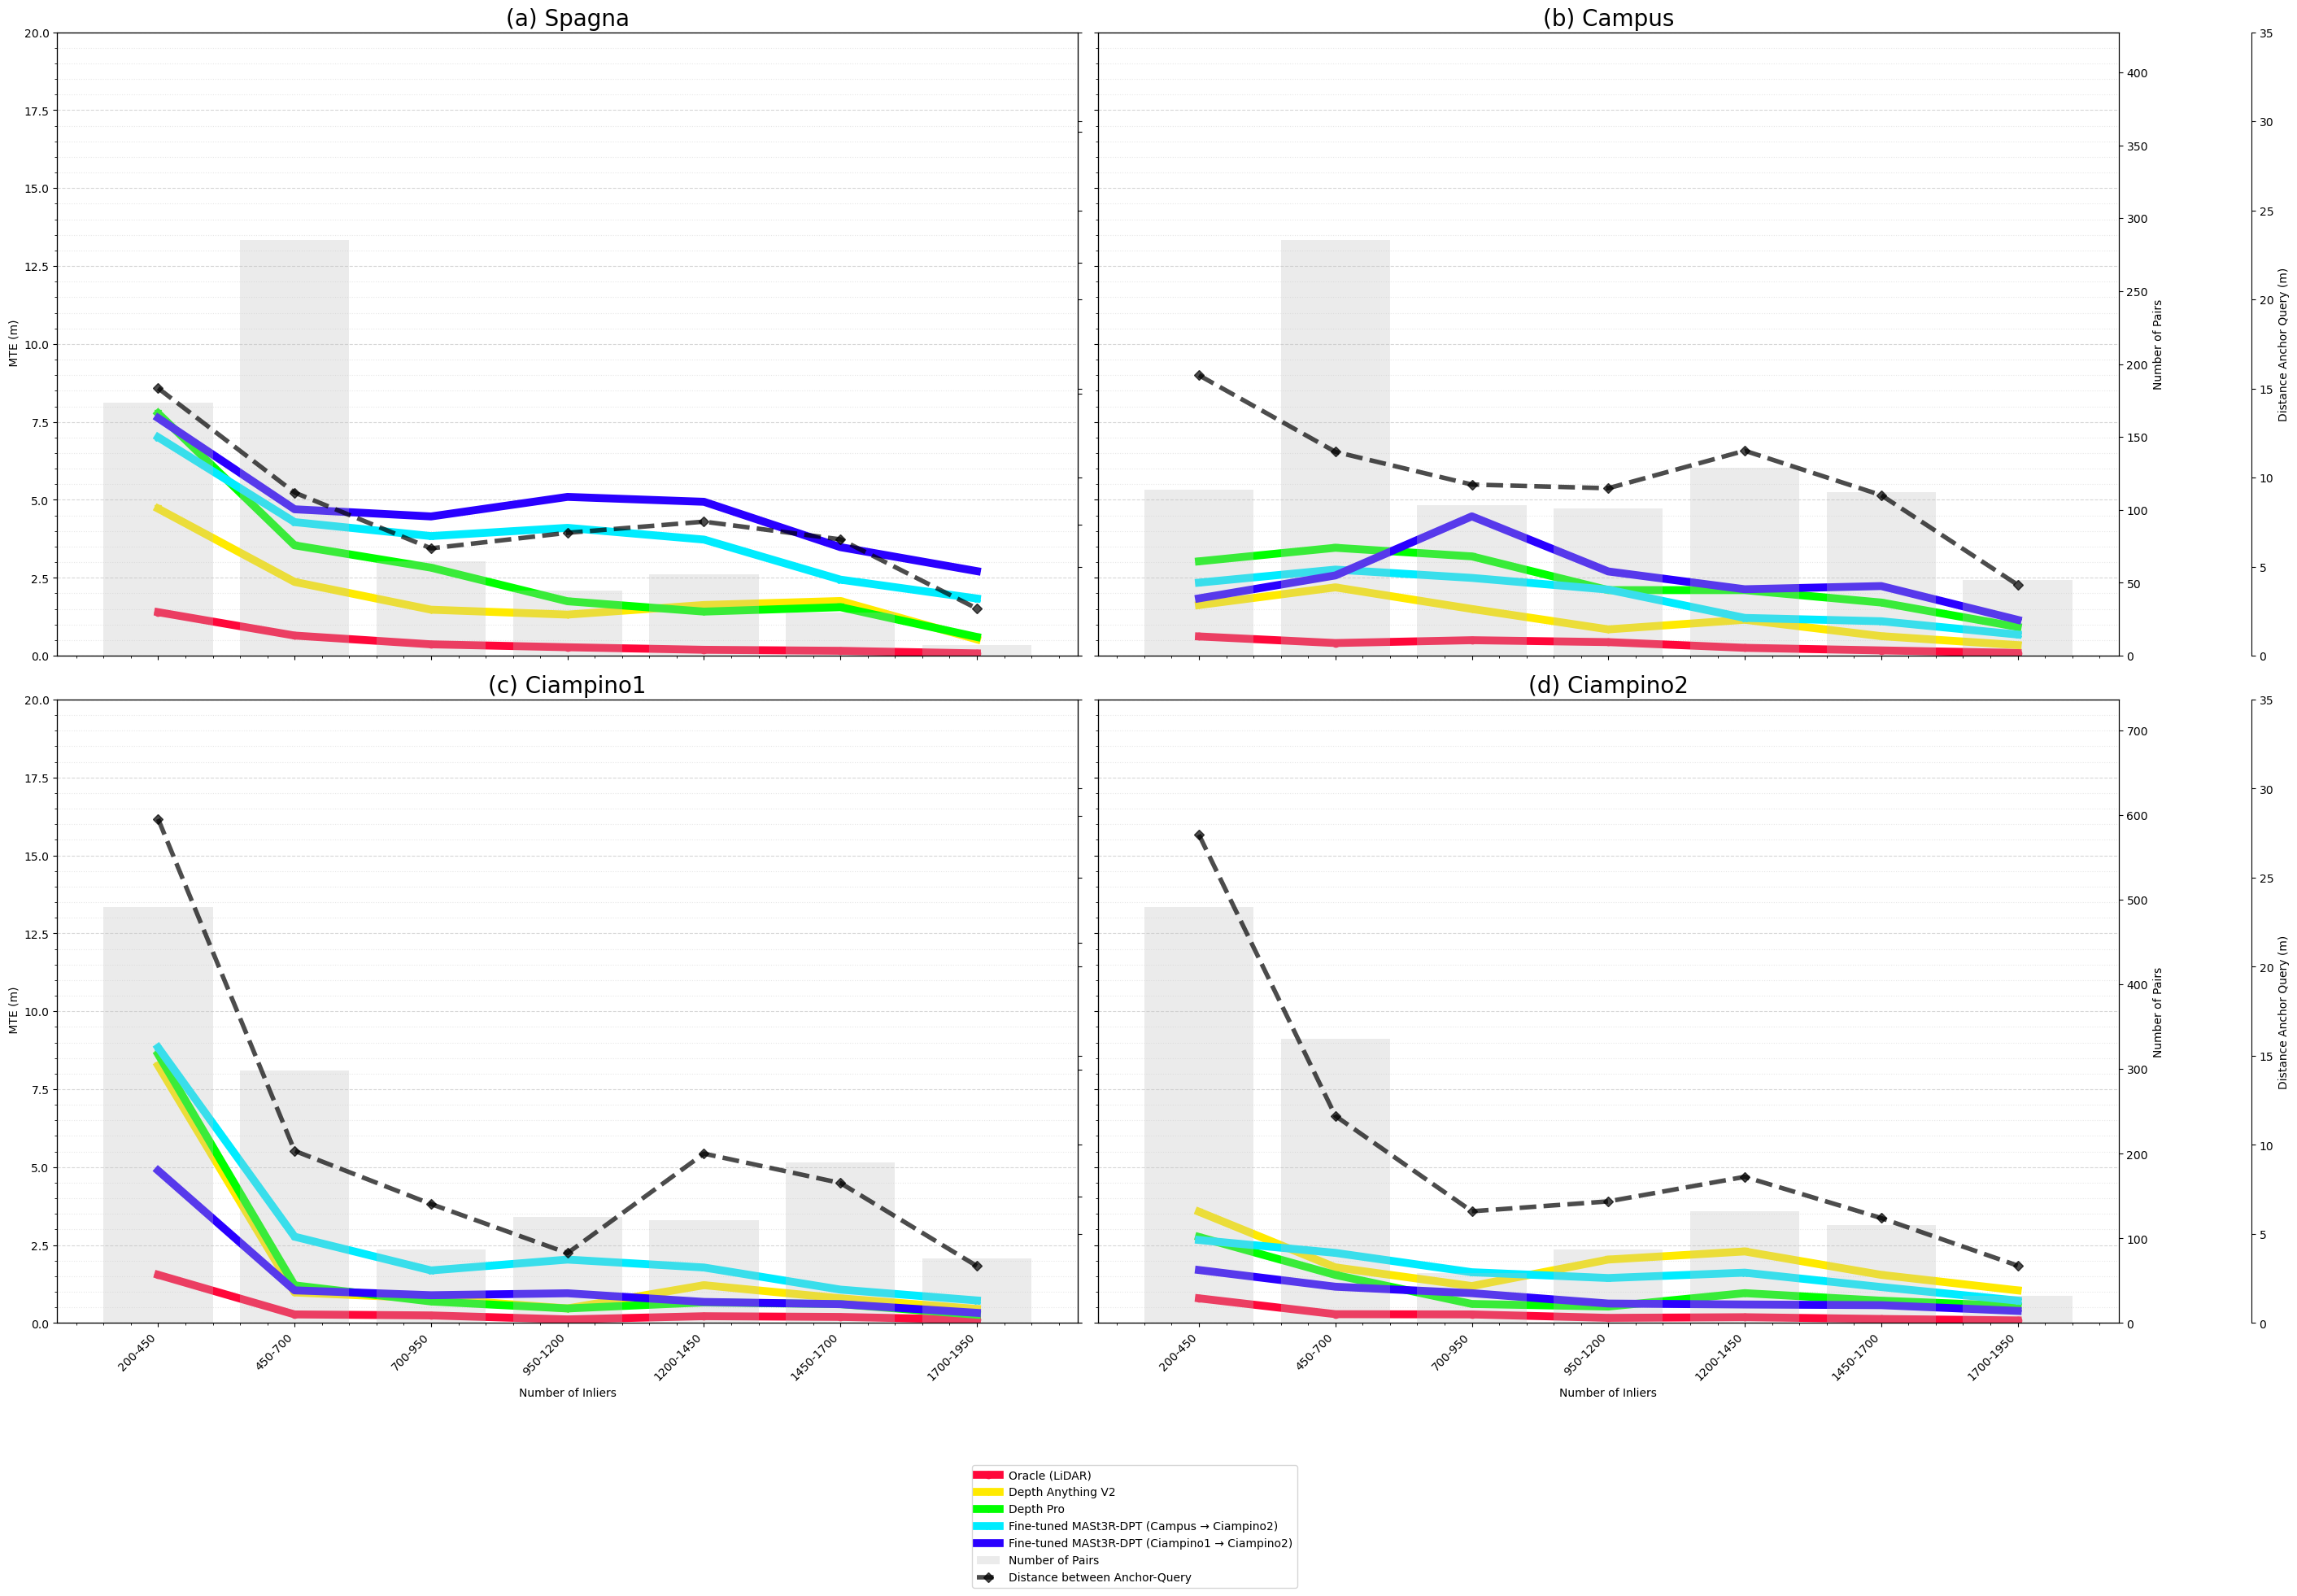

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm



# --- Config ---
reference_dataset = 'lidar_model_0'   # Oracle dataset
bin_width = 250
bin_by = 'n_inliers'

bin_min = 200
bin_max = 2200
fontsize = 15
metric_to_compare = 'pos_error'

# Define distinct colors, ensuring LiDAR is red
methods_to_compare = {
    'lidar_model_0': {
        'marker': 'o', 'linestyle': '-', 'label': 'Oracle (LiDAR)', 'color': '#FF073A'  # Red
    },
    # 'mast3r_model_0': {
    #     'marker': '^', 'linestyle': '-', 'label': 'MASt3R-DPT', 'color': '#1E90FF'  # Blue
    # },
    # 'mast3r_model_1': {
    #     'marker': '^', 'linestyle': '--', 'label': 'MASt3R-DPT Confidence Thresholded', 'color': '#87CEFA'  # Brown
    # },
    # 'mast3r_scaled_v4_model_0': {
    #     'marker': 'P', 'linestyle': '-', 'label': 'MASt3R-DPT Scaled - Per Axis L1 Norm (LiDAR used at test time)', 'color': '#ff7f00'  # Orange
    # },
    #     'mast3r_scaled_v2_model_0': {
    #     'marker': 'P', 'linestyle': '-', 'label': 'MASt3R-DPT Scaled - Per Axis L2 Norm (LiDAR used at test time)', 'color': '#ff7f00'  # Orange
    # },
    #     'mast3r_scaled_v3_model_0': {
    #     'marker': 'P', 'linestyle': '-', 'label': 'MASt3R-DPT Scaled - Mean Per Axis L2 Norm (Identical for each axis)', 'color': '#ff7f00'  # Orange
    # },
    #     'mast3r_scaled_icp_model_0': {
    #     'marker': 'P', 'linestyle': '-', 'label': 'MASt3R-DPT Scaled - Similarity Transform (LiDAR used at test time)', 'color': '#ff7f00'  # Orange
    # },
    # 'mast3r_scaled_v4_model_6': {
    #     'color': '#ff7f00', 'marker': 'D', 'linestyle': '-', 'label': 'Per Axis L1 Norm (From train set)'  # Orange
    # },
    'anydepth80_model_2': {
        'marker': 'v', 'linestyle': '-', 'label': 'Depth Anything V2', 'color': '#999999'  # Gray
    },
    'depthpro_model_7': {
        'marker': 'v', 'linestyle': '-', 'label': 'Depth Pro', 'color': '#f781bf'  # Pink
    },
    'mast3r_model_4': {
        'marker': 'X', 'linestyle': '-', 'label': 'Fine-tuned MASt3R-DPT (Campus \u2192 Ciampino2)', 'color': '#4daf4a'  # Green
    },
    'mast3r_model_5': {
        'marker': '*', 'linestyle': '-', 'label': 'Fine-tuned MASt3R-DPT (Ciampino1 \u2192 Ciampino2)', 'color': '#984ea3'  # Purple
    },
}

# Define titles for each subplot
titles = {
    "spagna_train0": "(a) Spagna",
    "campus_train0_campus_train1": "(b) Campus",
    "ciampino_train0": "(c) Ciampino1",
    "ciampino_train1": "(d) Ciampino2"
}

def generate_plot(scene_group_name, ax, loaded_data, bin_min=bin_min, bin_max=None, show_right_axis=True, show_xlabel=True, cmap_name='gist_rainbow'):  # Pass ax and loaded_data
    # --- Get reference dataset for binning ---
    df_ref = loaded_data[reference_dataset]
    df_ref_ok = df_ref[df_ref['status'] == 'OK']

    data_min = df_ref_ok[bin_by].min()
    data_max = df_ref_ok[bin_by].max()
    bin_min = bin_min if bin_min is not None else 0
    bin_max = bin_max if bin_max is not None else int(data_max) + bin_width

    bins = range(bin_min, bin_max, bin_width)
    bin_column = f"{bin_by}_bin"
    df_ref_ok[bin_column] = pd.cut(df_ref_ok[bin_by], bins=bins, right=False)

    grouped_ref = df_ref_ok.groupby(bin_column)
    count_by_bin = grouped_ref.size()
    median_inliers_by_bin = grouped_ref["n_inliers"].median()
    bin_midpoints = [interval.mid for interval in count_by_bin.index]

    # --- Collect metric data for each method ---
    method_data = {}
    for method_name, config in methods_to_compare.items():
        if method_name in loaded_data:
            df = loaded_data[method_name]
            df_ok = df[df['status'] == 'OK']
            df_ok[bin_column] = pd.cut(df_ok[bin_by], bins=bins, right=False)
            grouped = df_ok.groupby(bin_column)

            if metric_to_compare in df_ok.columns:
                metric_values = grouped[metric_to_compare].median()
                metric_values = metric_values.reindex(count_by_bin.index)
                method_data[method_name] = metric_values

    # --- Plot ---
    # fig, ax1 = plt.subplots(figsize=(14, 10)) #No longer create figure here
    ax1 = ax  # Use the provided axes object
    if not show_right_axis:
        ax1.set_ylabel(f" MTE (m)", color="black")
    else:
        ax1.set_yticklabels([])   # hide ticks
        ax1.set_ylabel("")        # remove label

        
    ax1.set_ylim(0,20)
    line_plots = []

    # Use a colormap for distinct colors
    n=6
    cmap = cm.get_cmap(cmap_name, n)
    colors = [cmap(i) for i in range(n)]

    for idx, (method_name, config) in enumerate(methods_to_compare.items()):
        if method_name in method_data:
            
            if method_name in ['mast3r_scaled_v4_model_0']:
                color = '#FFA500'  # Set a darker orange for mast3r_model_5
            # if method_name == 'lidar_model_0':
            #     color = '#FF073A'  
            elif method_name in ['mast3r_model_0', 'mast3r_model_1', 'lidar_model_0']:
                # color = '#FF0000'  
                color = config['color']
            # elif method_name in ['depthpro_model_7', 'anydepth80_model_2']:
            #     # color = '#FF0000'  
            #     continue
            else:
                color = colors[idx]  # Get color from the colormap
            line = ax1.plot(
                bin_midpoints, method_data[method_name],
                color=color,
                marker=config['marker'],
                linestyle=config['linestyle'],
                label=config['label'],
                linewidth=7, markersize=6, alpha=1
            )

            line_plots.append((line[0], config['label']))

    # --- Secondary axis: number of pairs ---
    ax2 = ax1.twinx()
    bars = ax2.bar(
        bin_midpoints, count_by_bin, color="#C0C0C0", width=bin_width * 0.8,
        alpha=0.3, label=f"Number of Pairs"
    )
    # ax2.set_ylabel("Number of Pairs", color="black")
    # ax2.tick_params(axis="y", labelcolor="black")

    if show_right_axis:
        ax2.set_ylabel("Number of Pairs", color="black")
    else:
        ax2.set_yticklabels([])   # hide ticks
        ax2.set_ylabel("")        # remove label

    # # --- Annotate bars ---
    # for bar, median_inliers in zip(bars, median_inliers_by_bin):
    #     if not pd.isna(median_inliers):
    #         ax2.text(
    #             bar.get_x() + bar.get_width() / 2,
    #             bar.get_height() + max(count_by_bin) * 0.02,
    #             f"I {median_inliers:.0f}",
    #             ha="center", va="bottom", color="#2C3E50", weight="bold"
    #         )

    # --- Third axis: distance anchor query ---
    if 'distance_anchor_query' in df_ref_ok.columns:
        distance_anchor_query_median = df_ref_ok.groupby(bin_column)['distance_anchor_query'].median()
        distance_anchor_query_median = distance_anchor_query_median.reindex(count_by_bin.index)

        ax3 = ax1.twinx()
        # ax3.set_ylabel("Distance Anchor Query (m)", color="black")
        # ax3.tick_params(axis="y", labelcolor="black")
        ax3.set_ylim(0, 35)
        line_distance = ax3.plot(
            bin_midpoints, distance_anchor_query_median,
            color="black", marker="D", linestyle="--", label="Distance between Anchor-Query",
            linewidth=4, markersize=6, alpha=0.7
        )
        line_plots.append((line_distance[0], "Distance between Anchor-Query"))
        if show_right_axis:
            ax3.spines["right"].set_position(("axes", 1.13))
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)
            ax3.set_ylabel("Distance Anchor Query (m)", color="black")
            ax3.tick_params(axis="y", labelcolor="black")
        else:
            ax3.set_yticklabels([])
            ax3.set_ylabel("")

    # --- Legend ---
    legend_items = [(bars, f"Number of Pairs")] + line_plots
    handles, labels = zip(*legend_items)
    # ax1.legend(handles, labels, loc="best", ncol=2) # Remove individual legends

    # --- Formatting ---
    x_label = "Number of Matches" if bin_by == 'n_matches' else "Number of Inliers"
    if show_xlabel:
        ax1.set_xlabel(x_label)
        ax1.set_xticks(bin_midpoints)
        ax1.set_xticklabels(
            [f"{int(interval.left)}-{int(interval.right)}" for interval in count_by_bin.index],
            rotation=45, ha="right"
        )
    else:
        ax1.set_xlabel("")
        ax1.set_xticks(bin_midpoints)
        ax1.set_xticklabels([])   # hide labels on the top row

    ax2.set_ylim(0, max(count_by_bin) * 1.5)

    ax1.minorticks_on()
    ax1.grid(which="minor", axis="y", linestyle=":", alpha=0.3)
    ax1.grid(which="major", axis="y", linestyle="--", alpha=0.5)

    ax1.set_title(titles[scene_group_name], fontsize=20)  # Set title for each subplot
    # plt.tight_layout()
    # plt.savefig(f"pos_error_vs_inliers_{scene_group_name}.pdf", bbox_inches="tight")  # vector graphic


scene_groups = [
    ["spagna_train0"],
    ["campus_train0", "campus_train1"],  # Combined campus scenes
    ["ciampino_train0"],  # Separate ciampino scene,
    ["ciampino_train1"]
]

split = "test2"

# --- Create a single figure and axes for all subplots ---
# --- Create a single figure and axes for all subplots ---
ncols = 2
fig, axes = plt.subplots(2, 2, figsize=(28, 20))  # 2x2 grid
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# --- Load data and generate plots for each scene group ---
all_handles = []
all_labels = []

# # Assign LiDAR color outside the loop
# methods_to_compare['lidar_model_0']['color'] = '#e41a1c'  # Red

for i, scene_group in enumerate(scene_groups):  # Iterate through scene groups
    row = i // ncols
    col = i % ncols
    show_right_axes = (col == ncols - 1)       # only the rightmost subplot of each row
    show_xlabel = (row == 1)                   # only the bottom row shows x-axis labels
    loaded_data = {}  # Reset loaded_data for each scene
    if len(scene_group) > 1:
        scene_name = "_".join(scene_group)  # Combine scene names for the group
        print(f"--- Processing combined scene: {scene_name} ---")
    else:
        scene_name = scene_group[0]
        print(f"--- Processing scene: {scene_name} ---")

    # Specify which results to load from which base path
    result_specifications = {}
    for model_key, model_data in BASE_PATHS.items():
        for pointcloud_type in model_data["types"]:
            result_specifications[f"{pointcloud_type}_{model_key}"] = {
                "pointcloud_type": pointcloud_type,
                "base_path_key": model_key
            }

    for new_key, spec in result_specifications.items():
        pointcloud_type = spec["pointcloud_type"]
        base_path_key = spec["base_path_key"]
        base_path = BASE_PATHS[base_path_key]["path"]
        base_path_index = list(BASE_PATHS.keys()).index(base_path_key)  # Get index from key order

        df = load_statistics(pointcloud_type, [base_path], scene_group, base_path_index, split=split)  # Pass scene_group
        if df is not None:
            # Convert numeric columns
            numeric_columns = ["n_matches", "n_inliers", "n_overlapping", "median_depth",
                               "x_error", "y_error", "z_error", "pos_error", "rot_error",
                               "distance_anchor_query", "pointmap_error", "pointmap_error_x",
                               "pointmap_error_y", "pointmap_error_z"]

            scale_cols = [col for col in df.columns if col.startswith("scale")]
            numeric_columns.extend(scale_cols)

            for col in numeric_columns:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")

            # print(f"Creating key: {new_key}")  # Debugging print
            loaded_data[new_key] = df
        else:
            print(f"No data loaded for {pointcloud_type} in {base_path}")  # Debugging print

    # generate_plot(scene_name, axes[i], loaded_data, bin_max=2200)  # Pass the axes object and loaded_data
    generate_plot(scene_name, axes[i], loaded_data, bin_max=2200,show_right_axis=show_right_axes, show_xlabel=show_xlabel) 

# --- Add a single legend to the entire figure ---
# collect legend entries from all subplots
handles, labels = [], []
for ax in axes:
    for a in [ax] + ax.figure.axes:  # include twins
        h, l = a.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# remove duplicates while keeping order
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
handles, labels = zip(*unique)

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=1)


plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # Adjust layout to make room for the legend
# plt.savefig("pos_error_vs_inliers_combined.pdf", bbox_inches